# Customer Churn EDA

This notebook explores the Telco Customer Churn dataset to understand the structure of the data and look for early patterns related to customer churn. We will focus only on exploration and visualization in this step, without doing feature engineering or model training.

## 1. Import Libraries and Load the Dataset

We start by importing the libraries we need and loading the dataset into a pandas DataFrame. Then we inspect the dataset shape, column names, data types, and a few sample rows so we know what we are working with.

In [1]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

file_path = '../data/WA_Fn-UseC_-Telco-Customer-Churn.csv'
df = pd.read_csv(file_path)

print(f'Dataset shape: {df.shape}')
print('\nColumn names:')
print(df.columns.tolist())
print('\nData types:')
display(df.dtypes.to_frame('dtype'))
print('\nFirst 5 rows:')
display(df.head())

Dataset shape: (7043, 21)

Column names:
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

Data types:


,dtype
customerID,object
gender,object
SeniorCitizen,int64
Partner,object
Dependents,object
tenure,int64
PhoneService,object
MultipleLines,object
InternetService,object
OnlineSecurity,object



First 5 rows:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 2. Check Missing Values and Duplicates

Before we analyze churn, it is a good habit to check the overall data quality. Here we look for missing values and duplicate rows, because both can affect the quality of later analysis.

In [2]:
missing_values = df.isna().sum().sort_values(ascending=False)
duplicate_count = df.duplicated().sum()

print('Missing values by column:')
display(missing_values.to_frame('missing_count'))
print(f'Duplicate rows: {duplicate_count}')

Missing values by column:


,missing_count
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


Duplicate rows: 0


## 3. Clean the `TotalCharges` Column

The `TotalCharges` column should be numeric, but in this dataset it may contain blank strings instead of proper missing values. That can happen for very new customers who have not yet built up total charges.

We will:
1. Detect blank strings in `TotalCharges`
2. Convert the column to numeric using `errors='coerce'`, which turns invalid values into `NaN`
3. Drop the small number of rows with missing `TotalCharges` for this EDA step, because they cannot be used in numeric summaries and plots involving that column

In [3]:
blank_total_charges = df['TotalCharges'].astype(str).str.strip().eq('').sum()
print(f'Blank strings in TotalCharges before conversion: {blank_total_charges}')

df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
missing_total_charges = df['TotalCharges'].isna().sum()
print(f'Missing values in TotalCharges after conversion: {missing_total_charges}')

eda_df = df.dropna(subset=['TotalCharges']).copy()
print(f'Rows before cleaning: {len(df)}')
print(f'Rows after dropping missing TotalCharges: {len(eda_df)}')

Blank strings in TotalCharges before conversion: 11
Missing values in TotalCharges after conversion: 11
Rows before cleaning: 7043
Rows after dropping missing TotalCharges: 7032


## 4. Basic Statistics for Numeric Columns

Now that the numeric columns are in the correct format, we can use summary statistics to understand their typical values, spread, and range. This gives us a quick high-level view of the dataset.

In [4]:
numeric_df = eda_df.select_dtypes(include='number')
display(numeric_df.describe().T)

,count,mean,std,min,25%,50%,75%,max
SeniorCitizen,7032.0,0.162400,0.368844,0.00,0.0000,0.000,0.0000,1.00
tenure,7032.0,32.421786,24.545260,1.00,9.0000,29.000,55.0000,72.00
MonthlyCharges,7032.0,64.798208,30.085974,18.25,35.5875,70.350,89.8625,118.75
TotalCharges,7032.0,2283.300441,2266.771362,18.80,401.4500,1397.475,3794.7375,8684.80


## 5. Churn Distribution

Our target column is `Churn`. Before comparing churn against other features, we should first understand how many customers churned and what percentage of the dataset they represent.

In [5]:
churn_counts = eda_df['Churn'].value_counts()
churn_percentages = eda_df['Churn'].value_counts(normalize=True).mul(100).round(2)

print('Churn counts:')
display(churn_counts.to_frame('count'))
print('Churn percentages:')
display(churn_percentages.to_frame('percentage'))

Churn counts:


,count
Churn,
No,5163
Yes,1869


Churn percentages:


,percentage
Churn,
No,73.42
Yes,26.58


## 6. Visualize Churn Distribution

A countplot gives us a simple visual check of class balance. This helps us see whether churned customers are much fewer than non-churned customers.

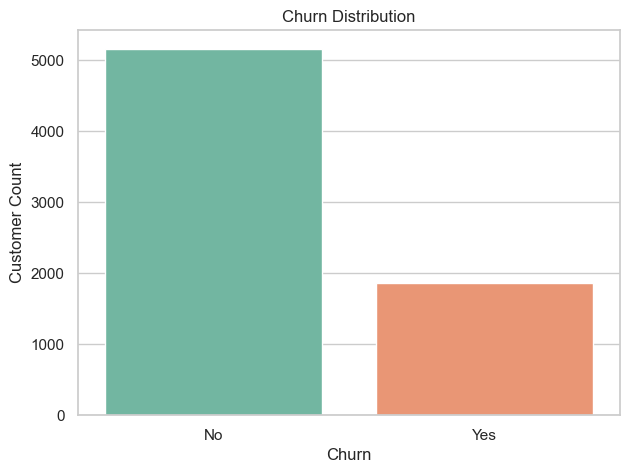

In [6]:
plt.figure(figsize=(7, 5))
sns.countplot(data=eda_df, x='Churn', hue='Churn', palette='Set2', legend=False)
plt.title('Churn Distribution')
plt.xlabel('Churn')
plt.ylabel('Customer Count')
plt.show()

## 7. Churn Rate by Contract Type

Contract length often affects retention. Here we calculate the churn rate within each contract type so we can compare month-to-month customers against longer contracts.

Churn,No,Yes
Contract,,
Month-to-month,57.29,42.71
One year,88.72,11.28
Two year,97.15,2.85


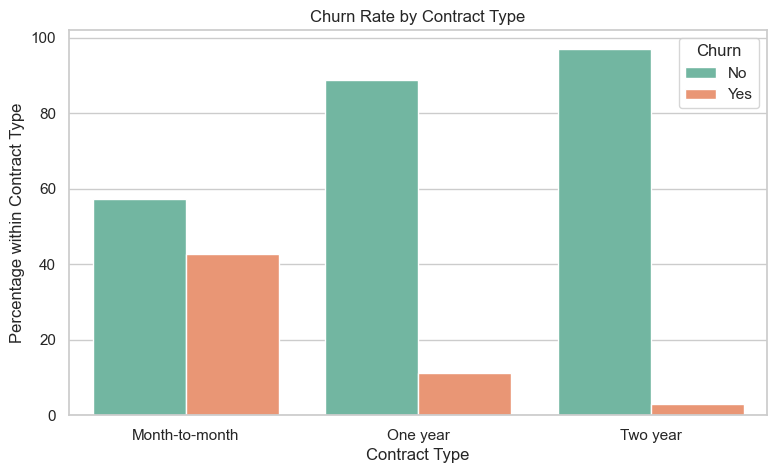

In [7]:
contract_churn = (
    pd.crosstab(eda_df['Contract'], eda_df['Churn'], normalize='index')
    .mul(100)
    .round(2)
)
display(contract_churn)

contract_churn_reset = contract_churn.reset_index().melt(
    id_vars='Contract',
    var_name='Churn',
    value_name='Percentage'
)

plt.figure(figsize=(9, 5))
sns.barplot(data=contract_churn_reset, x='Contract', y='Percentage', hue='Churn', palette='Set2')
plt.title('Churn Rate by Contract Type')
plt.xlabel('Contract Type')
plt.ylabel('Percentage within Contract Type')
plt.legend(title='Churn')
plt.show()

## 8. Churn Rate by Tenure Group

Tenure tells us how long a customer has stayed with the company. Grouping it into simple ranges makes it easier to compare churn behavior across newer and more established customers.

Churn,No,Yes
tenure_group,,
0-12 months,52.32,47.68
12-24 months,71.29,28.71
24-48 months,79.61,20.39
48+ months,90.49,9.51


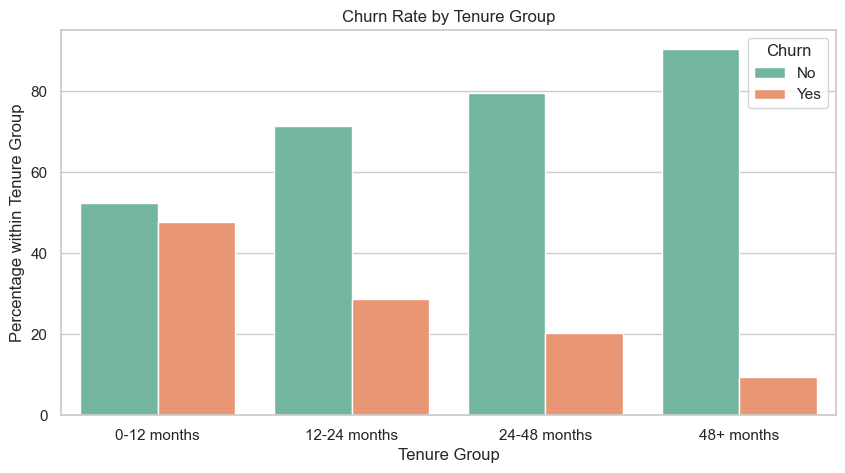

In [8]:
eda_df['tenure_group'] = pd.cut(
    eda_df['tenure'],
    bins=[0, 12, 24, 48, np.inf],
    labels=['0-12 months', '12-24 months', '24-48 months', '48+ months'],
    include_lowest=True
)

tenure_churn = (
    pd.crosstab(eda_df['tenure_group'], eda_df['Churn'], normalize='index')
    .mul(100)
    .round(2)
)
display(tenure_churn)

tenure_churn_reset = tenure_churn.reset_index().melt(
    id_vars='tenure_group',
    var_name='Churn',
    value_name='Percentage'
)

plt.figure(figsize=(10, 5))
sns.barplot(data=tenure_churn_reset, x='tenure_group', y='Percentage', hue='Churn', palette='Set2')
plt.title('Churn Rate by Tenure Group')
plt.xlabel('Tenure Group')
plt.ylabel('Percentage within Tenure Group')
plt.legend(title='Churn')
plt.show()

## 9. Monthly Charges Distribution by Churn

Instead of only comparing averages, it is also useful to compare the full distribution of monthly charges for churned and non-churned customers. This helps us see whether higher monthly charges appear more often in customers who leave.

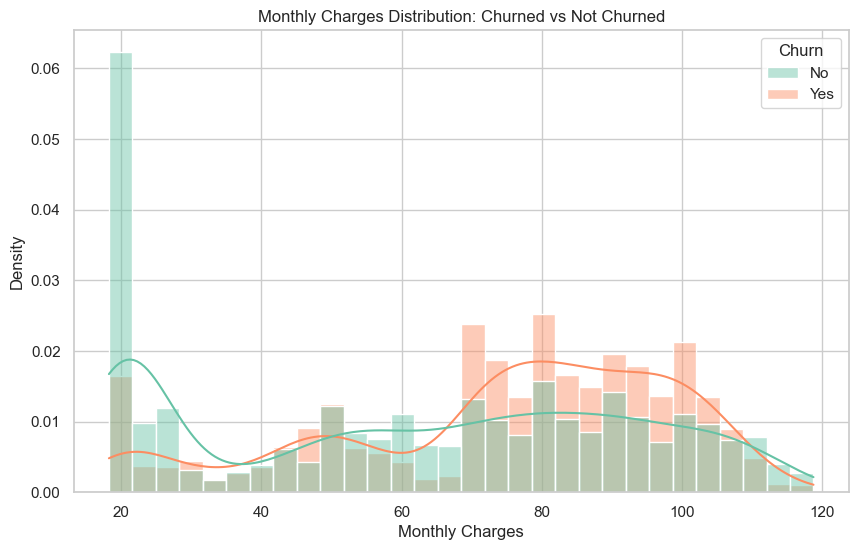

,MonthlyCharges,tenure,TotalCharges
Churn,,,
No,61.31,37.65,2555.34
Yes,74.44,17.98,1531.80


In [9]:
plt.figure(figsize=(10, 6))
sns.histplot(
    data=eda_df,
    x='MonthlyCharges',
    hue='Churn',
    kde=True,
    stat='density',
    common_norm=False,
    bins=30,
    palette='Set2',
    alpha=0.45
)
plt.title('Monthly Charges Distribution: Churned vs Not Churned')
plt.xlabel('Monthly Charges')
plt.ylabel('Density')
plt.show()

display(eda_df.groupby('Churn')[['MonthlyCharges', 'tenure', 'TotalCharges']].mean().round(2))

## 10. Correlation Heatmap for Numeric Features

A correlation heatmap helps us understand how numeric features move together. This does not prove cause and effect, but it gives us a quick way to spot strong relationships in the data.

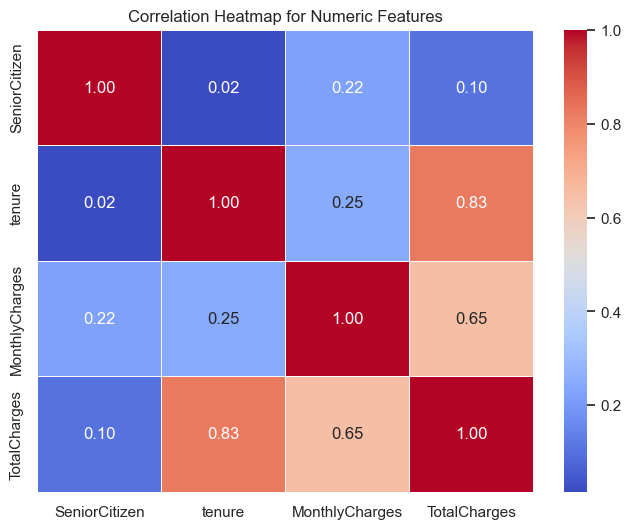

In [10]:
correlation_matrix = numeric_df.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap for Numeric Features')
plt.show()

## 11. EDA Summary and Key Insights

Based on this exploratory analysis, here are the main takeaways:

1. The dataset is moderately imbalanced: about 73.46% of customers did not churn, while about 26.54% did churn.
2. `TotalCharges` contained 11 blank string values. Converting the column to numeric and dropping those rows was a simple and appropriate cleanup step for EDA.
3. Contract type appears strongly related to churn: month-to-month customers have much higher churn than customers on one-year or two-year contracts.
4. Churn is much higher among newer customers. Customers in the 0-12 month group churn far more often than customers with longer tenure.
5. Customers who churn tend to have higher monthly charges on average, but lower tenure and lower total charges, suggesting that short customer lifetime and pricing may both matter.